# Inverse PINN for the 1D viscous Burgers equation

In this notebook, we use a PINN to solve an **inverse problem**.

The PDE is

$$
\partial_t u + u\partial_x u = \nu \partial_{xx}u.
$$

In the forward problem, $\nu$ is known.

In the inverse problem, $\nu$ is unknown.
We try to learn $\nu$ from observed data.

The PINN learns both:

$$
u_\theta(t,x)
$$

and

$$
\nu.
$$

We will generate synthetic observation data using a simple finite-difference method.
Then, the PINN will use sparse observations and the PDE residual to estimate $\nu$.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## True Burgers equation

We assume the true viscosity is

$$
\nu_{\text{true}} = \frac{0.01}{\pi}.
$$

The initial and boundary conditions are

$$
u(0,x)=-\sin(\pi x),
$$

$$
u(t,-1)=u(t,1)=0.
$$

In [2]:
T = 1.0
x_min, x_max = -1.0, 1.0

nu_true = 0.01 / np.pi
print("nu_true =", nu_true)

nu_true = 0.003183098861837907


## Generate synthetic observation data using FDM

Here we use finite difference only to generate data.

The PINN will not be given $\nu_{\text{true}}$.
It only receives sparse observations of $u(t,x)$.

In [4]:
def burgers_fdm_upwind(nu, Nx=256, T=1.0, dt=2.0e-4):
    """
    Simple explicit FDM solver for viscous Burgers equation.

    PDE:
        u_t + u u_x = nu u_xx

    IC:
        u(0,x) = -sin(pi x)

    BC:
        u(t,-1) = u(t,1) = 0

    Upwind difference is used for the convection term.
    Central difference is used for the diffusion term.
    """
    x = np.linspace(-1.0, 1.0, Nx + 1)
    dx = x[1] - x[0]

    Nt = int(T / dt)
    t = np.linspace(0.0, T, Nt + 1)

    u = -np.sin(np.pi * x)
    u[0] = 0.0
    u[-1] = 0.0

    U = np.zeros((Nt + 1, Nx + 1))
    U[0, :] = u.copy()

    for n in range(Nt):
        un = u.copy()

        # Upwind derivative for convection
        ux_backward = (un[1:-1] - un[0:-2]) / dx
        ux_forward = (un[2:] - un[1:-1]) / dx

        ux_upwind = np.where(un[1:-1] >= 0.0, ux_backward, ux_forward)

        # Central difference for diffusion
        uxx = (un[2:] - 2.0 * un[1:-1] + un[0:-2]) / dx**2

        u[1:-1] = un[1:-1] - dt * un[1:-1] * ux_upwind + dt * nu * uxx

        # Boundary conditions
        u[0] = 0.0
        u[-1] = 0.0

        U[n + 1, :] = u.copy()

    return x, t, U


x_fdm, t_fdm, U_fdm = burgers_fdm_upwind(nu_true, Nx=256, T=T, dt=2.0e-4)

print("x_fdm:", x_fdm.shape)
print("t_fdm:", t_fdm.shape)
print("U_fdm:", U_fdm.shape)

x_fdm: (257,)
t_fdm: (5001,)
U_fdm: (5001, 257)


## Visualize generated data

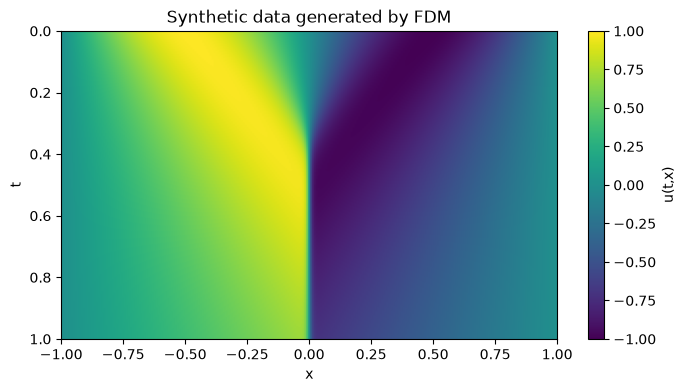

In [5]:
plt.figure(figsize=(8, 4))
plt.imshow(
    U_fdm,
    extent=[x_min, x_max, T, 0],
    aspect="auto"
)
plt.colorbar(label="u(t,x)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Synthetic data generated by FDM")
plt.show()

## Sparse observations

We sample a small number of points from the FDM solution.

These points play the role of measurements:

$$
\{(t_i,x_i,u_i)\}_{i=1}^{N_{\text{obs}}}.
$$

In [6]:
# -----------------------
# Sample sparse observation points
# -----------------------
N_obs = 2000

Nt_total, Nx_total = U_fdm.shape

t_indices = np.random.randint(0, Nt_total, size=N_obs)
x_indices = np.random.randint(0, Nx_total, size=N_obs)

t_obs_np = t_fdm[t_indices].reshape(-1, 1)
x_obs_np = x_fdm[x_indices].reshape(-1, 1)
u_obs_np = U_fdm[t_indices, x_indices].reshape(-1, 1)

tx_obs = torch.tensor(
    np.concatenate([t_obs_np, x_obs_np], axis=1),
    dtype=torch.float32
).to(device)

u_obs = torch.tensor(u_obs_np, dtype=torch.float32).to(device)

print("tx_obs:", tx_obs.shape)
print("u_obs:", u_obs.shape)

tx_obs: torch.Size([2000, 2])
u_obs: torch.Size([2000, 1])


## Collocation points for the PDE residual

The collocation points are used to enforce the PDE:

$$
u_t + uu_x - \nu u_{xx}=0.
$$

These points do not require observation values.

In [7]:
N_f = 5000

t_col = torch.rand(N_f, 1).to(device) * T
x_col = x_min + (x_max - x_min) * torch.rand(N_f, 1).to(device)
tx_col = torch.cat([t_col, x_col], dim=1)

print("tx_col:", tx_col.shape)

tx_col: torch.Size([5000, 2])


## Boundary and initial-condition points

We also include initial and boundary information to stabilize the inverse PINN.

In [8]:
def initial_condition_torch(x):
    return -torch.sin(np.pi * x)


N_ic = 256
N_bc = 256

# Initial condition
x_ic = torch.linspace(x_min, x_max, N_ic).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic).to(device)
tx_ic = torch.cat([t_ic, x_ic], dim=1)
u_ic = initial_condition_torch(x_ic)

# Boundary condition
t_bc = torch.rand(N_bc, 1).to(device) * T

x_left = torch.full_like(t_bc, x_min).to(device)
x_right = torch.full_like(t_bc, x_max).to(device)

tx_bc_left = torch.cat([t_bc, x_left], dim=1)
tx_bc_right = torch.cat([t_bc, x_right], dim=1)

u_bc_left = torch.zeros_like(t_bc).to(device)
u_bc_right = torch.zeros_like(t_bc).to(device)

## Neural network and learnable viscosity

We represent the solution by

$$
u_\theta(t,x).
$$

The viscosity is represented by a learnable parameter.

To force positivity, we use

$$
\nu = \mathrm{softplus}(\rho),
$$

where $\rho$ is an unconstrained trainable parameter.

In [24]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden_layers=4):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, tx):
        return self.net(tx)


class InverseBurgersPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = MLP(hidden_dim=64, num_hidden_layers=4)

        # Initial guess for viscosity.
        # softplus(raw_nu) will be positive.
        initial_nu_guess = 0.02
        self.raw_nu = nn.Parameter(
            torch.tensor(
                np.log(np.exp(initial_nu_guess) - 1.0),
                dtype=torch.float32
            )
        )

    def forward(self, tx):
        return self.net(tx)

    def viscosity(self):
        return F.softplus(self.raw_nu)


model = InverseBurgersPINN().to(device)
print("initial learned nu =", model.viscosity().item())

initial learned nu = 0.019999997690320015


## PDE residual with unknown viscosity

The residual is

$$
r_\theta(t,x)
=
\partial_t u_\theta
+
u_\theta \partial_x u_\theta
-
\nu \partial_{xx}u_\theta.
$$

Here $\nu$ is also optimized during training.

In [25]:
def burgers_residual_inverse(model, tx):
    tx = tx.clone().detach().requires_grad_(True)

    u = model(tx)

    grad_u = torch.autograd.grad(
        u,
        tx,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_t = grad_u[:, 0:1]
    u_x = grad_u[:, 1:2]

    grad_u_x = torch.autograd.grad(
        u_x,
        tx,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_xx = grad_u_x[:, 1:2]

    nu = model.viscosity()
    residual = u_t + u * u_x - nu * u_xx

    return residual

## Train inverse PINN

The inverse PINN loss is

$$
\mathcal{L}
=
\mathcal{L}_{data}
+
\mathcal{L}_{IC}
+
\mathcal{L}_{BC}
+
\mathcal{L}_{PDE}.
$$

The data loss is

$$
\mathcal{L}_{data}
=
\frac{1}{N_{\text{obs}}}
\sum_i
|u_\theta(t_i,x_i)-u_i|^2.
$$

In [26]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

num_epochs = 10000
print_every = 500

loss_history = []
loss_data_history = []
loss_pde_history = []
nu_history = []

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()

    # Observation/data loss
    u_pred_obs = model(tx_obs)
    loss_data = torch.mean((u_pred_obs - u_obs) ** 2)

    # Initial condition loss
    u_pred_ic = model(tx_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic) ** 2)

    # Boundary condition loss
    u_pred_left = model(tx_bc_left)
    u_pred_right = model(tx_bc_right)
    loss_bc = torch.mean((u_pred_left - u_bc_left) ** 2) + torch.mean((u_pred_right - u_bc_right) ** 2)

    # PDE residual loss
    residual = burgers_residual_inverse(model, tx_col)
    loss_pde = torch.mean(residual ** 2)

    loss = loss_data + loss_ic + loss_bc + loss_pde
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    loss_data_history.append(loss_data.item())
    loss_pde_history.append(loss_pde.item())
    nu_history.append(model.viscosity().item())

    if epoch % print_every == 0 or epoch == 1:
        print(
            f"epoch {epoch:5d} | "
            f"loss={loss.item():.4e} | "
            f"data={loss_data.item():.4e} | "
            f"PDE={loss_pde.item():.4e} | "
            f"nu={model.viscosity().item():.6f}"
        )

print("true nu    =", nu_true)
print("learned nu =", model.viscosity().item())

epoch     1 | loss=8.5418e-01 | data=3.6412e-01 | PDE=2.2377e-04 | nu=0.020020
epoch   500 | loss=4.7585e-02 | data=1.7464e-02 | PDE=1.1706e-02 | nu=0.030418
epoch  1000 | loss=2.3528e-02 | data=1.2235e-02 | PDE=7.3824e-03 | nu=0.030117
epoch  1500 | loss=1.7774e-02 | data=1.0419e-02 | PDE=5.2859e-03 | nu=0.028254
epoch  2000 | loss=1.4768e-02 | data=9.1297e-03 | PDE=4.1475e-03 | nu=0.026295
epoch  2500 | loss=1.2473e-02 | data=7.9596e-03 | PDE=3.3766e-03 | nu=0.024421
epoch  3000 | loss=1.0835e-02 | data=7.1038e-03 | PDE=2.9528e-03 | nu=0.022629
epoch  3500 | loss=9.7620e-03 | data=6.1931e-03 | PDE=2.5362e-03 | nu=0.020992
epoch  4000 | loss=7.9073e-03 | data=5.2643e-03 | PDE=2.1112e-03 | nu=0.019711
epoch  4500 | loss=6.7931e-03 | data=4.5148e-03 | PDE=1.8407e-03 | nu=0.018246
epoch  5000 | loss=6.0425e-03 | data=3.9450e-03 | PDE=1.6843e-03 | nu=0.017081
epoch  5500 | loss=5.2234e-03 | data=3.3911e-03 | PDE=1.4912e-03 | nu=0.015916
epoch  6000 | loss=4.7421e-03 | data=3.0225e-03 | PD

## Loss curves

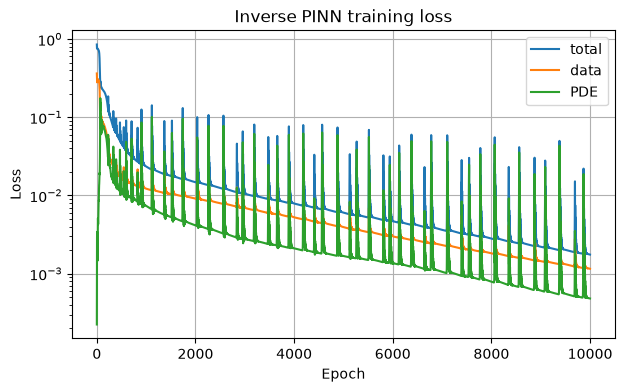

In [27]:
plt.figure(figsize=(7, 4))
plt.semilogy(loss_history, label="total")
plt.semilogy(loss_data_history, label="data")
plt.semilogy(loss_pde_history, label="PDE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Inverse PINN training loss")
plt.legend()
plt.grid(True)
plt.show()

## Viscosity estimation history

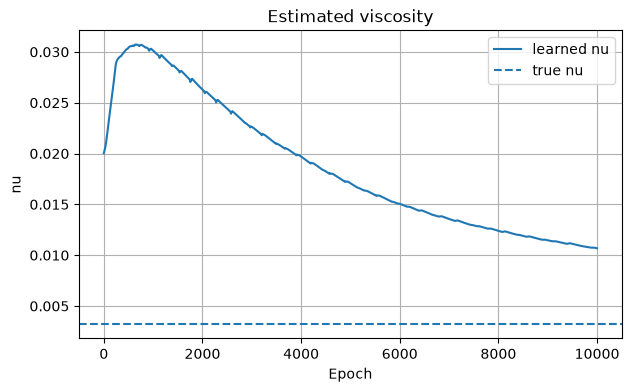

true nu    = 0.003183098861837907
learned nu = 0.01068135816603899


In [28]:
plt.figure(figsize=(7, 4))
plt.plot(nu_history, label="learned nu")
plt.axhline(nu_true, linestyle="--", label="true nu")
plt.xlabel("Epoch")
plt.ylabel("nu")
plt.title("Estimated viscosity")
plt.legend()
plt.grid(True)
plt.show()

print("true nu    =", nu_true)
print("learned nu =", nu_history[-1])

## Compare learned solution with FDM data

In [29]:
# -----------------------
# Prediction grid
# -----------------------
Nx_plot = len(x_fdm)
Nt_plot = 101

x_plot = torch.tensor(x_fdm, dtype=torch.float32).view(-1, 1).to(device)
t_plot_np = np.linspace(0.0, T, Nt_plot)
t_plot = torch.tensor(t_plot_np, dtype=torch.float32).view(-1, 1).to(device)

TT, XX = torch.meshgrid(
    t_plot.squeeze(),
    x_plot.squeeze(),
    indexing="ij"
)

tx_grid = torch.stack([TT.reshape(-1), XX.reshape(-1)], dim=1)

model.eval()
with torch.no_grad():
    U_pinn = model(tx_grid).reshape(Nt_plot, Nx_plot).detach().cpu().numpy()

# FDM values at same plotting times
fdm_indices = [np.argmin(np.abs(t_fdm - tt)) for tt in t_plot_np]
U_fdm_plot = U_fdm[fdm_indices, :]

print("U_pinn:", U_pinn.shape)
print("U_fdm_plot:", U_fdm_plot.shape)

U_pinn: (101, 257)
U_fdm_plot: (101, 257)


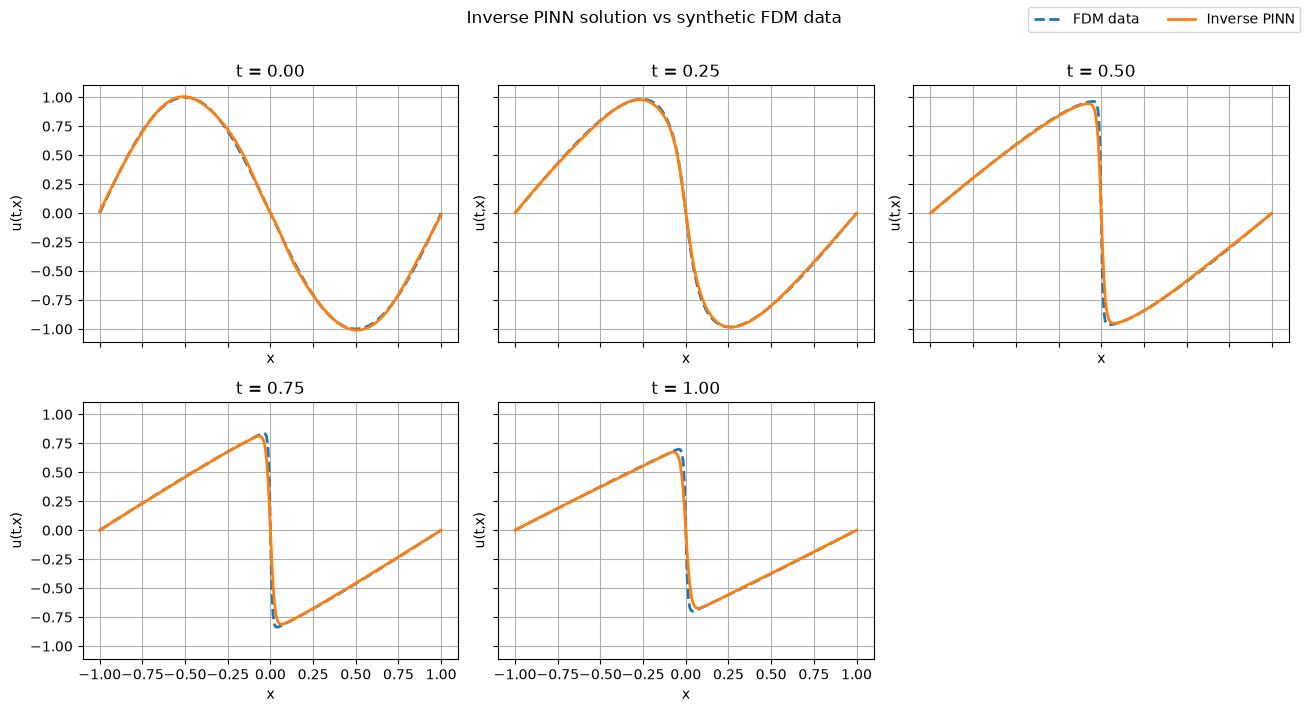

In [30]:
# -----------------------
# Clear comparison by subplots
# -----------------------
times_to_plot = [0.0, 0.25, 0.50, 0.75, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
axes = axes.flatten()

for k, t_now in enumerate(times_to_plot):
    ax = axes[k]

    idx_pinn = np.argmin(np.abs(t_plot_np - t_now))
    idx_fdm = np.argmin(np.abs(t_fdm - t_now))

    ax.plot(
        x_fdm,
        U_fdm[idx_fdm, :],
        "--",
        linewidth=2,
        label="FDM data"
    )

    ax.plot(
        x_fdm,
        U_pinn[idx_pinn, :],
        "-",
        linewidth=2,
        label="Inverse PINN"
    )

    ax.set_title(f"t = {t_now:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(t,x)")
    ax.grid(True)

fig.suptitle("Inverse PINN solution vs synthetic FDM data", y=1.01)


# Remove the unused subplot
axes[-1].axis("off")

# # Use one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,  ncol=2)

plt.tight_layout()
plt.show()

## Observation points

The inverse PINN only used sparse observations, not the full FDM solution.

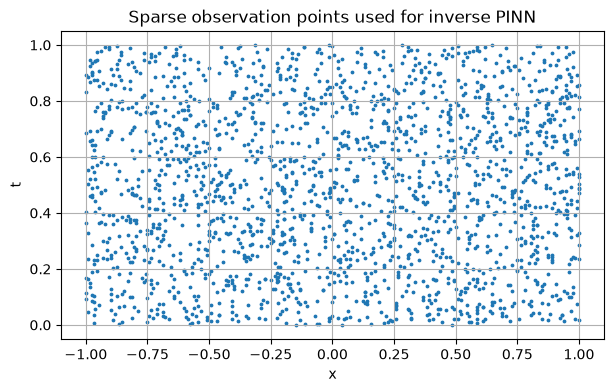

In [31]:
plt.figure(figsize=(7, 4))
plt.scatter(x_obs_np, t_obs_np, s=3)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Sparse observation points used for inverse PINN")
plt.grid(True)
plt.show()

## Remark

In this inverse problem, the PINN learns the physical parameter $\nu$ together with the solution.

This is different from a standard supervised model because the PDE residual helps identify the parameter.
The data alone gives observations of $u$, but the PDE tells the model how $u$ should evolve.